<a href="https://colab.research.google.com/github/vivekchavan2401/CSL701-CE04_Machine-Learning-Lab/blob/main/MLExp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: VIVEK VIKAS CHAVAN

Roll_No:CE04

In [19]:
# TASK 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [20]:
# TASK 2: Load Auto MPG dataset

url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"
0.
df = pd.read_csv(url)

print(df.head())


    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [21]:
# TASK 3: Inspect and clean data

print(df.info())
print(df.isnull().sum())

df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

df = df.dropna(
    subset=["horsepower", "mpg"]
)

print("Cleaned data:")
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB
None
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64
Cleaned data:
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0       

In [22]:
# TASK 4: Select horsepower and MPG

X = df["horsepower"].values
y = df["mpg"].values

print("Horsepower:")
print(X[:10])

print("MPG:")
print(y[:10])



Horsepower:
[130 165 150 150 140 198 220 215 225 190]
MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


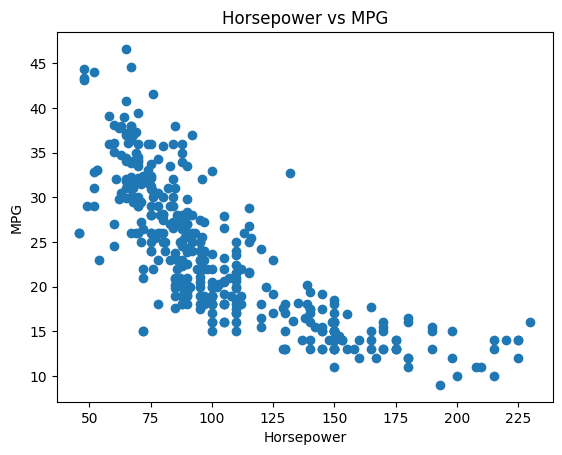

In [23]:
# TASK 5: Plot scatter graph

plt.scatter(X, y)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")

plt.show()


In [24]:
# TASK 6: Add bias term

X = X.reshape(-1, 1)

X_bias = np.c_[
    np.ones(X.shape[0]),
    X
]

print("X with bias:")
print(X_bias[:5])


X with bias:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


In [25]:
# TASK 7: Compute correlation

correlation = np.corrcoef(
    df["horsepower"],
    df["mpg"]
)[0, 1]

print("Correlation =", correlation)



Correlation = -0.7784267838977756


In [26]:
# TASK 8: Calculate OLS weights

# w = (X^T X)^-1 X^T y

w = np.linalg.inv(
    X_bias.T @ X_bias
) @ X_bias.T @ y

print("OLS Weights:")
print("Intercept =", w[0])
print("Slope =", w[1])


OLS Weights:
Intercept = 39.9358610211705
Slope = -0.15784473335365387


In [27]:
# TASK 9: Predict values

y_pred = X_bias @ w

print("Predicted values:")
print(y_pred[:10])



Predicted values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [28]:
# TASK 10: Compute residuals

residuals = y - y_pred

print("Residuals:")
print(residuals[:10])


Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [29]:
# TASK 11: Calculate SSE, MSE, R²

SSE = np.sum(
    (y - y_pred) ** 2
)

MSE = np.mean(
    (y - y_pred) ** 2
)

SST = np.sum(
    (y - np.mean(y)) ** 2
)

R2 = 1 - (SSE / SST)

print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)


SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


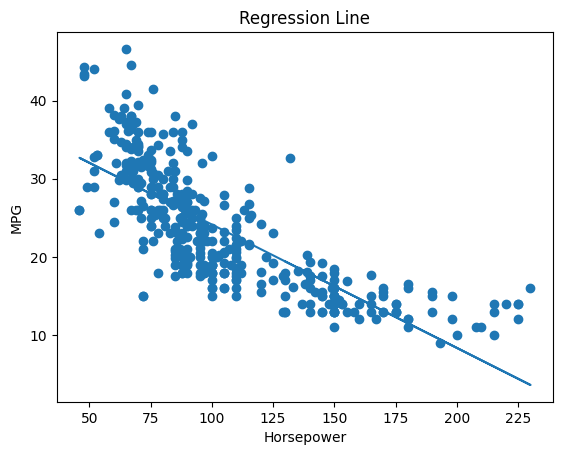

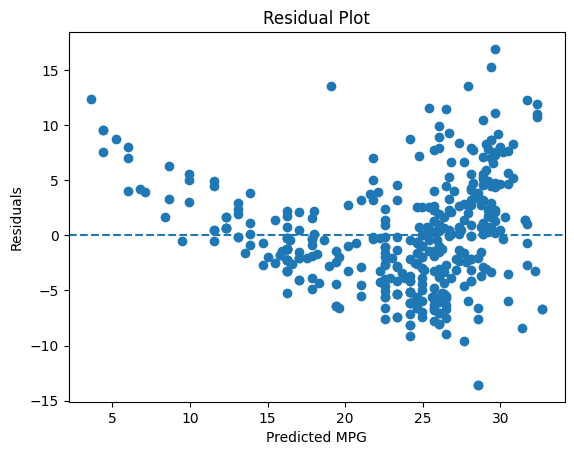

In [30]:
# TASK 12: Plot regression and residual graphs

# Regression graph

plt.scatter(X, y)
plt.plot(X, y_pred)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regression Line")

plt.show()


# Residual graph

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()



In [31]:
# TASK 13: Interpret results

print("Regression Equation:")

print(
    "MPG = {:.4f} + ({:.4f} × Horsepower)".format(
        w[0],
        w[1]
    )
)

if w[1] < 0:
    print(
        "Horsepower has a negative relationship with MPG."
    )
    print(
        "As horsepower increases, MPG decreases."
    )
else:
    print(
        "Horsepower has a positive relationship with MPG."
    )
    print(
        "As horsepower increases, MPG increases."
    )

print("R² =", R2)


Regression Equation:
MPG = 39.9359 + (-0.1578 × Horsepower)
Horsepower has a negative relationship with MPG.
As horsepower increases, MPG decreases.
R² = 0.6059482578894348


In [32]:
# TASK 14: Upload Google Colab onto GitHub repository

print(
    "Task 14: Upload the completed Google Colab notebook "
    "(.ipynb) to your GitHub repository."
)

Task 14: Upload the completed Google Colab notebook (.ipynb) to your GitHub repository.
